# Maser Model Selection - Combined Analysis (v2, finalized)

Single merged notebook for the maser probability model recommendation. Replaces the two divergent notebooks (Cam's `maser_02_analysis` and Claire's `Claire_Analysis`).

**Synthetic data only.** Real galaxy feature distributions with simulated labels, so performance is measured against known ground truth. The real catalogs appear once, as a context figure, and no model is ever fit on them.

Hyperparameter sweeps are **not** in this notebook. The winners were selected in the sweep notebooks on seeds 0-4; everything reported here runs on seeds 5-44, disjoint from selection.

## 0. Locked protocol

Every setting that caused the two notebooks to disagree, resolved:

| Setting | Value | Why |
|---|---|---|
| `ceiling` | repo default 0.4, never passed | Inclination lottery; asserted at startup so a stale clone fails loudly |
| `strength` | 3.0 everywhere, including figures | The old scenario panel silently rendered at the library default 2.5 |
| CV | 5-fold, 1 repeat, 40 seeds | Between-seed sd ~0.08 vs within-seed repeat sd ~0.026, so budget goes to seeds |
| fold seed | `1000*seed + repeat` | Decorrelates fold structure from the data draw; identical folds for every model at a given (seed, repeat) |
| selection seeds | 0-4 (in the sweep notebooks) | |
| report seeds | 5-44 (40 seeds) | Disjoint from selection, kills the leak; count is where the repeat budget went |
| LR solver | `lbfgs` | `liblinear` penalizes the intercept, inflating promised totals at 8% prevalence |
| RF | `max_features="sqrt"` | A forest subsets features; bagged trees do not |
| boosting | sklearn `HistGradientBoostingClassifier` | No extra dependency to drift between machines |
| prec@50 | one OOF pass per repeat, each galaxy counted once | The old pooled version counted every galaxy 4x |
| all metrics | computed on the full OOF pass, then averaged over repeats | Previously some were per-fold means and some pooled |
| dataset build | once per (scenario, seed), shared by all models | Same catalog and same folds for every model; pairing is exact by construction |
| error bars | standard error over seeds | std is the population spread, not the precision of the mean |
| model comparison | paired per-seed differences vs `lr_linear` | Unpaired differences under ~0.05 are unresolvable here; paired 0.02 is |

## 1. Setup and provenance

In [59]:
import os, sys, subprocess, time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

REPO_URL = "https://github.com/spragunr/maser-research"
REPO_DIR = "maser-research"
PIN      = None          # set to a commit SHA to freeze the generator

try:
    _ip = str(get_ipython())
except NameError:
    _ip = ""

if "google.colab" in _ip:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    # fetch+reset, not a bare existence check: a stale clone must not survive
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "--all", "--quiet"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard",
                    PIN or "origin/main", "--quiet"], check=True)
    os.chdir(REPO_DIR)

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
for _p in ("src", "../src"):
    _ap = os.path.abspath(_p)
    if os.path.isdir(_ap) and _ap not in sys.path:
        sys.path.insert(0, _ap)

# ONE import path for the generator. Do not also import src.synth_data:
# that creates a second module object for the same file.
import synth_data as sd
from maser_data import FEATURES, TARGET

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

import warnings
warnings.filterwarnings("ignore")

In [60]:
# ---- provenance guard: run this first, paste the output when comparing runs ----
try:
    _sha = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"],
                                   text=True).strip()
except Exception:
    _sha = "unknown"

_chk = sd.make_dataset("xray", scenario="blob", strength=3.0, seed=0)
print("synth_data :", sd.__file__)
print("repo sha   :", _sha)
print("ceiling    :", _chk.attrs.get("ceiling"))
print("p_true.max :", round(float(_chk["p_true"].max()), 3))

assert _chk.attrs.get("ceiling") == 0.4, \
    "generator is not at ceiling=0.4 - you are on a stale copy of synth_data.py"
assert _chk["p_true"].max() <= 0.4, "p_true exceeds the ceiling"
print("\nprovenance OK")

synth_data : /content/maser-research/src/synth_data.py
repo sha   : ba181b0
ceiling    : 0.4
p_true.max : 0.287

provenance OK


In [61]:
# ---- global config: identical for every model and plane ----
SCENARIOS   = ["linear", "wedge", "box", "interaction", "blob"]
STRENGTH    = 3.0
WISE_SIGNAL = 1.0            # fused-plane default; section 7 sweeps this knob
N_AT        = 50

N_SPLITS    = 5
N_REPEATS   = 1
SELECT_SEEDS = range(0, 5)   # used by the sweep notebooks, NOT here
REPORT_SEEDS = range(5, 45)  # everything in this notebook (40 seeds)
WS_SEEDS     = range(5, 15)  # section 7 only: the sweep is 10x the work

N_JOBS      = -1             # outer-loop parallelism; models stay single-threaded
WISE_N      = None           # full WISE catalog

XRAY_FEATS,  XRAY_TGT  = FEATURES["xray"], TARGET["xray"]
WISE_FEATS,  WISE_TGT  = FEATURES["wise"], TARGET["wise"]
FUSED_FEATS, FUSED_TGT = sd.FUSED["columns"], sd.FUSED["target"]

PRIMARY_METRICS    = ["prec_at_n", "mse_vs_truth"]
DIAGNOSTIC_METRICS = ["brier", "pr_auc", "auc"]
METRICS            = PRIMARY_METRICS + DIAGNOSTIC_METRICS
PROMISE_FIELDS     = ["promised_at_n", "delivered_at_n",
                      "promised_total", "actual_total", "true_expected_total"]
HIGHER_BETTER      = {"auc": True, "pr_auc": True, "prec_at_n": True,
                      "brier": False, "mse_vs_truth": False}
BASELINE_MODEL     = "lr_linear"

print(f"report seeds: {list(REPORT_SEEDS)[0]}-{list(REPORT_SEEDS)[-1]} "
      f"({len(list(REPORT_SEEDS))} seeds) x {N_REPEATS} repeats x {N_SPLITS} folds")
for _n, _f, _t in [("xray", XRAY_FEATS, XRAY_TGT), ("wise", WISE_FEATS, WISE_TGT),
                   ("fused", FUSED_FEATS, FUSED_TGT)]:
    print(f"{_n:5s} features: {_f} | target: {_t}")

report seeds: 5-44 (40 seeds) x 1 repeats x 5 folds
xray  features: ['L_12um_bestfit_1', 'Lob'] | target: is_megamaser_plus
wise  features: ['w1w2', 'w2w3'] | target: is_megamaser
fused features: ['L_12um_bestfit_1', 'Lob', 'wise_w1w2', 'wise_w2w3'] | target: is_megamaser_plus


In [62]:
# ---- calibration-reference guard ----
# The generator defines p_obs = p_true * sensitivity. Models learn the OBSERVABLE
# process, so mse_vs_truth (measured against p_true) is a valid calibration
# reference only while p_obs == p_true. Under the current config (no distance
# noise) they are equal. This fails loudly if that ever changes.
for _sc in SCENARIOS:
    for _plane, _d in [
        ("xray",  sd.make_dataset("xray", scenario=_sc, strength=STRENGTH, seed=0)),
        ("wise",  sd.make_dataset("wise", scenario=_sc, strength=STRENGTH, n=WISE_N, seed=0)),
        ("fused", sd.make_fused_dataset(scenario=_sc, wise_signal=WISE_SIGNAL,
                                        strength=STRENGTH, seed=0)),
    ]:
        assert np.allclose(_d["p_true"], _d["p_obs"]), (
            f"{_plane}/{_sc}: p_obs != p_true - point mse_vs_truth at p_obs "
            "before trusting calibration numbers")
print("calibration reference OK (p_obs == p_true)")

calibration reference OK (p_obs == p_true)


## 2. Model builders

Each builder returns a zero-argument callable producing a fresh estimator, so every fold gets an untouched model.

In [63]:
def make_lr(features="plain", C=1.0):
    """features: plain | interaction | quadratic. Solver is lbfgs, which leaves
    the intercept unpenalized - liblinear shrinks it and inflates the promised
    totals at 8% prevalence."""
    def build():
        steps = [StandardScaler()]
        if features == "interaction":
            steps.append(PolynomialFeatures(2, interaction_only=True, include_bias=False))
        elif features == "quadratic":
            steps.append(PolynomialFeatures(2, interaction_only=False, include_bias=False))
        steps.append(LogisticRegression(C=C, solver="lbfgs", max_iter=5000))
        return make_pipeline(*steps)
    return build

def make_rf(n_estimators=150, max_depth=4, min_samples_leaf=5):
    """max_features='sqrt': a random forest subsets features at each split.
    Setting it to the full feature count gives bagged trees, not a forest."""
    return lambda: RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, max_features="sqrt",
        random_state=0, n_jobs=1)

def make_hgb(max_depth=2, learning_rate=0.05, max_iter=150):
    """sklearn's histogram GBT. Chosen over XGBoost so the notebook has no
    dependency that can differ between machines."""
    return lambda: HistGradientBoostingClassifier(
        max_iter=max_iter, max_depth=max_depth,
        learning_rate=learning_rate, random_state=0)

## 3. Frozen lineups

Winners carried over from the sweep notebooks, which ran on seeds 0-4.

Caveat worth stating on any writeup: the boosting winners were originally selected under XGBoost and are mapped onto the equivalent HistGB depth and learning rate here. The LR and RF winners transfer directly. If the boosting row ever becomes the recommendation, re-sweep it under HistGB before claiming it.

In [64]:
TUNED = {
    "xray": {
        "lr_linear":    make_lr("plain",     C=1.0),   # baseline, never tuned away
        "lr_quadratic": make_lr("quadratic", C=1.0),
        "rf":           make_rf(n_estimators=150, max_depth=4, min_samples_leaf=10),
        "hgb":          make_hgb(max_depth=2, learning_rate=0.05),
    },
    "wise": {
        "lr_linear":    make_lr("plain",     C=1.0),
        "lr_quadratic": make_lr("quadratic", C=0.1),
        "rf":           make_rf(n_estimators=150, max_depth=3, min_samples_leaf=10),
        "hgb":          make_hgb(max_depth=2, learning_rate=0.05),
    },
    "fused": {
        "lr_linear":    make_lr("plain",     C=1.0),
        "lr_quadratic": make_lr("quadratic", C=0.1),
        "rf":           make_rf(n_estimators=150, max_depth=4, min_samples_leaf=5),
        "hgb":          make_hgb(max_depth=3, learning_rate=0.05),
    },
}

MODEL_ORDER = ["lr_linear", "lr_quadratic", "rf", "hgb"]

# dataset factories so one harness serves every plane
def xray_dataset_fn(scenario):
    return lambda seed: sd.make_dataset("xray", scenario=scenario,
                                        strength=STRENGTH, seed=seed)

def wise_dataset_fn(scenario):
    return lambda seed: sd.make_dataset("wise", scenario=scenario,
                                        strength=STRENGTH, n=WISE_N, seed=seed)

def fused_dataset_fn(scenario):
    return lambda seed: sd.make_fused_dataset(scenario=scenario,
                                              wise_signal=WISE_SIGNAL,
                                              strength=STRENGTH, seed=seed)

for _p, _m in TUNED.items():
    print(f"{_p:5s} lineup: {list(_m)}")

xray  lineup: ['lr_linear', 'lr_quadratic', 'rf', 'hgb']
wise  lineup: ['lr_linear', 'lr_quadratic', 'rf', 'hgb']
fused lineup: ['lr_linear', 'lr_quadratic', 'rf', 'hgb']


## 4. Evaluation harness

One definition of every metric, used everywhere.

Per seed: the catalog is generated **once** and shared by every model, and each model sees the identical fold split (`random_state = 1000*seed + repeat`). Per repeat: a single 5-fold out-of-fold pass in which each galaxy is predicted exactly once. All metrics, including prec@50, come from that one pass. Repeats are averaged, and the harness returns **one row per (model, seed)** so downstream code can do paired comparisons that are exact by construction.

In [65]:
def _metrics_on(build, d, feats, tgt, seed, n_repeats=N_REPEATS):
    """Averaged metrics for ONE model on ONE already-built catalog."""
    X  = d[feats].to_numpy()
    y  = d[tgt].to_numpy()
    pt = d["p_true"].to_numpy()

    reps = []
    for r in range(n_repeats):
        skf = StratifiedKFold(N_SPLITS, shuffle=True, random_state=1000 * seed + r)
        oof = np.full(len(y), np.nan)
        for tr, te in skf.split(X, y):
            # assert rather than silently skip: a dropped fold changes the
            # denominator and biases the mean toward the lucky folds
            assert y[te].sum() >= 1, f"degenerate fold: seed={seed} repeat={r}"
            oof[te] = build().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        assert not np.isnan(oof).any(), "some galaxy was never predicted"

        top = np.argsort(-oof)[:N_AT]
        reps.append({
            "auc":                 roc_auc_score(y, oof),
            "pr_auc":              average_precision_score(y, oof),
            "brier":               float(np.mean((oof - y) ** 2)),
            "mse_vs_truth":        float(np.mean((oof - pt) ** 2)),
            "prec_at_n":           float(y[top].mean()),
            "promised_at_n":       float(oof[top].sum()),
            "delivered_at_n":      float(y[top].sum()),
            "promised_total":      float(oof.sum()),
            "actual_total":        float(y.sum()),
            "true_expected_total": float(pt.sum()),
        })

    out = pd.DataFrame(reps).mean().to_dict()
    out["seed"] = seed
    out["n"]    = len(y)         # catalog size, for prevalence baselines later
    return out

def _eval_models_one_seed(builders, dataset_fn, feats, tgt, seed):
    """All models on the SAME catalog. One dataset build per (scenario, seed)
    instead of one per (model, scenario, seed): 4x less generation, and the
    paired comparison shares data and folds by construction. Top level so
    joblib can ship it to workers."""
    d = dataset_fn(seed)
    return {name: _metrics_on(b, d, feats, tgt, seed)
            for name, b in builders.items()}

def run_grid(models, dataset_fn_for, feats, tgt,
             seeds=REPORT_SEEDS, label_col="model"):
    """Tidy per-seed results. No aggregation happens here."""
    seeds = list(seeds)
    tasks = [(sc, s) for sc in SCENARIOS for s in seeds]
    t0 = time.time()
    res = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(_eval_models_one_seed)(models, dataset_fn_for(sc), feats, tgt, s)
        for sc, s in tasks
    )
    rows = [{label_col: name, "scenario": sc, **m}
            for (sc, _), per_model in zip(tasks, res)
            for name, m in per_model.items()]
    print(f"  {len(models)} models x {len(SCENARIOS)} scenarios x {len(seeds)} seeds "
          f"on {len(tasks)} shared catalogs in {time.time() - t0:.0f}s", flush=True)
    return pd.DataFrame(rows)

In [66]:
# ---- aggregation and display ----
def summarize(per_seed, metric, label_col="model"):
    """Mean and standard error over seeds, per (model, scenario)."""
    g    = per_seed.groupby([label_col, "scenario"])[metric]
    mean = g.mean().unstack("scenario")[SCENARIOS]
    se   = (g.std(ddof=1) / np.sqrt(g.count())).unstack("scenario")[SCENARIOS]
    mean["MEAN"] = mean[SCENARIOS].mean(axis=1)
    # approximate: treats scenarios as independent, which they are not exactly
    se["MEAN"] = np.sqrt((se[SCENARIOS] ** 2).sum(axis=1)) / len(SCENARIOS)
    order = mean["MEAN"].sort_values(ascending=not HIGHER_BETTER[metric]).index
    return mean.loc[order].round(3), se.loc[order].round(3)

def show_metric(per_seed, metric, label_col="model"):
    role = "PRIMARY" if metric in PRIMARY_METRICS else "diagnostic"
    m, e = summarize(per_seed, metric, label_col)
    print(f"===== {metric} ({role}; higher better: {HIGHER_BETTER[metric]}) "
          f"- mean +/- SE over {per_seed['seed'].nunique()} seeds =====")
    display(m.astype(str) + " +/- " + e.astype(str))

def paired_table(per_seed, metric, label_col="model", baseline=BASELINE_MODEL):
    """Per-seed difference against the baseline model, joined on (scenario, seed).
    The datasets cancel, so the SE is far smaller than on either raw mean."""
    base = (per_seed[per_seed[label_col] == baseline]
            .set_index(["scenario", "seed"])[metric])
    rows = []
    for name, g in per_seed.groupby(label_col):
        if name == baseline:
            continue
        d  = g.set_index(["scenario", "seed"])[metric] - base
        gm = d.groupby("scenario")
        mean, se, n = gm.mean(), gm.std(ddof=1) / np.sqrt(gm.count()), gm.count()
        for sc in SCENARIOS:
            rows.append({label_col: name, "scenario": sc,
                         "diff": mean[sc], "se": se[sc],
                         "t": mean[sc] / se[sc] if se[sc] > 0 else np.nan,
                         "n": int(n[sc])})
    return pd.DataFrame(rows)

def show_paired(per_seed, metric, label_col="model", baseline=BASELINE_MODEL):
    t = paired_table(per_seed, metric, label_col, baseline)
    cell = (t["diff"].round(3).astype(str) + " +/- " + t["se"].round(3).astype(str)
            + t["t"].apply(lambda v: "  *" if abs(v) >= 2 else ""))
    out = (t.assign(cell=cell)
            .pivot(index=label_col, columns="scenario", values="cell")[SCENARIOS])
    print(f"===== {metric}: paired difference vs {baseline} "
          f"(higher better: {HIGHER_BETTER[metric]}; * = |t| >= 2) =====")
    display(out)

def promise_topn_table(per_seed, label_col="model"):
    a = per_seed.groupby([label_col, "scenario"])[["promised_at_n", "delivered_at_n"]].mean()
    p = a["promised_at_n"].unstack("scenario")[SCENARIOS]
    d = a["delivered_at_n"].unstack("scenario")[SCENARIOS]
    out = pd.concat({"promised": p, "delivered": d}, axis=1).swaplevel(axis=1)
    return out.reindex(columns=pd.MultiIndex.from_product(
        [SCENARIOS, ["promised", "delivered"]])).round(1)

def promise_total_table(per_seed, label_col="model"):
    t = (per_seed.groupby([label_col, "scenario"])["promised_total"].mean()
         .unstack("scenario")[SCENARIOS])
    t.loc["ACTUAL masers"]     = per_seed.groupby("scenario")["actual_total"].mean()[SCENARIOS]
    t.loc["ORACLE (sum p_true)"] = per_seed.groupby("scenario")["true_expected_total"].mean()[SCENARIOS]
    return t.round(1)

## 5. Data overview

Context figures only. Nothing here feeds the evaluation.

In [67]:
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.family": "DejaVu Sans",
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "axes.linewidth": .9, "axes.edgecolor": "#3A3A3A",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "savefig.bbox": "tight",
    "savefig.facecolor": "white", "figure.facecolor": "white",
})
from matplotlib.lines import Line2D

NEG, POS, REAL_POS = "#B9C2CC", "#C2452D", "#1F5C8B"
PLANE_LABELS = {
    "xray": ("X-ray plane", "log L_12um", "log L_obs (2-10 keV)"),
    "wise": ("WISE plane",  "W1 - W2",    "W2 - W3"),
}

SAVE_FIGS = True
FIG_DIR   = "poster_figs"
if SAVE_FIGS:
    os.makedirs(FIG_DIR, exist_ok=True)

def _save(fig, name):
    if SAVE_FIGS:
        path = os.path.join(FIG_DIR, f"{name}.png")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("saved", path)

saved poster_figs/scenario_panel.png


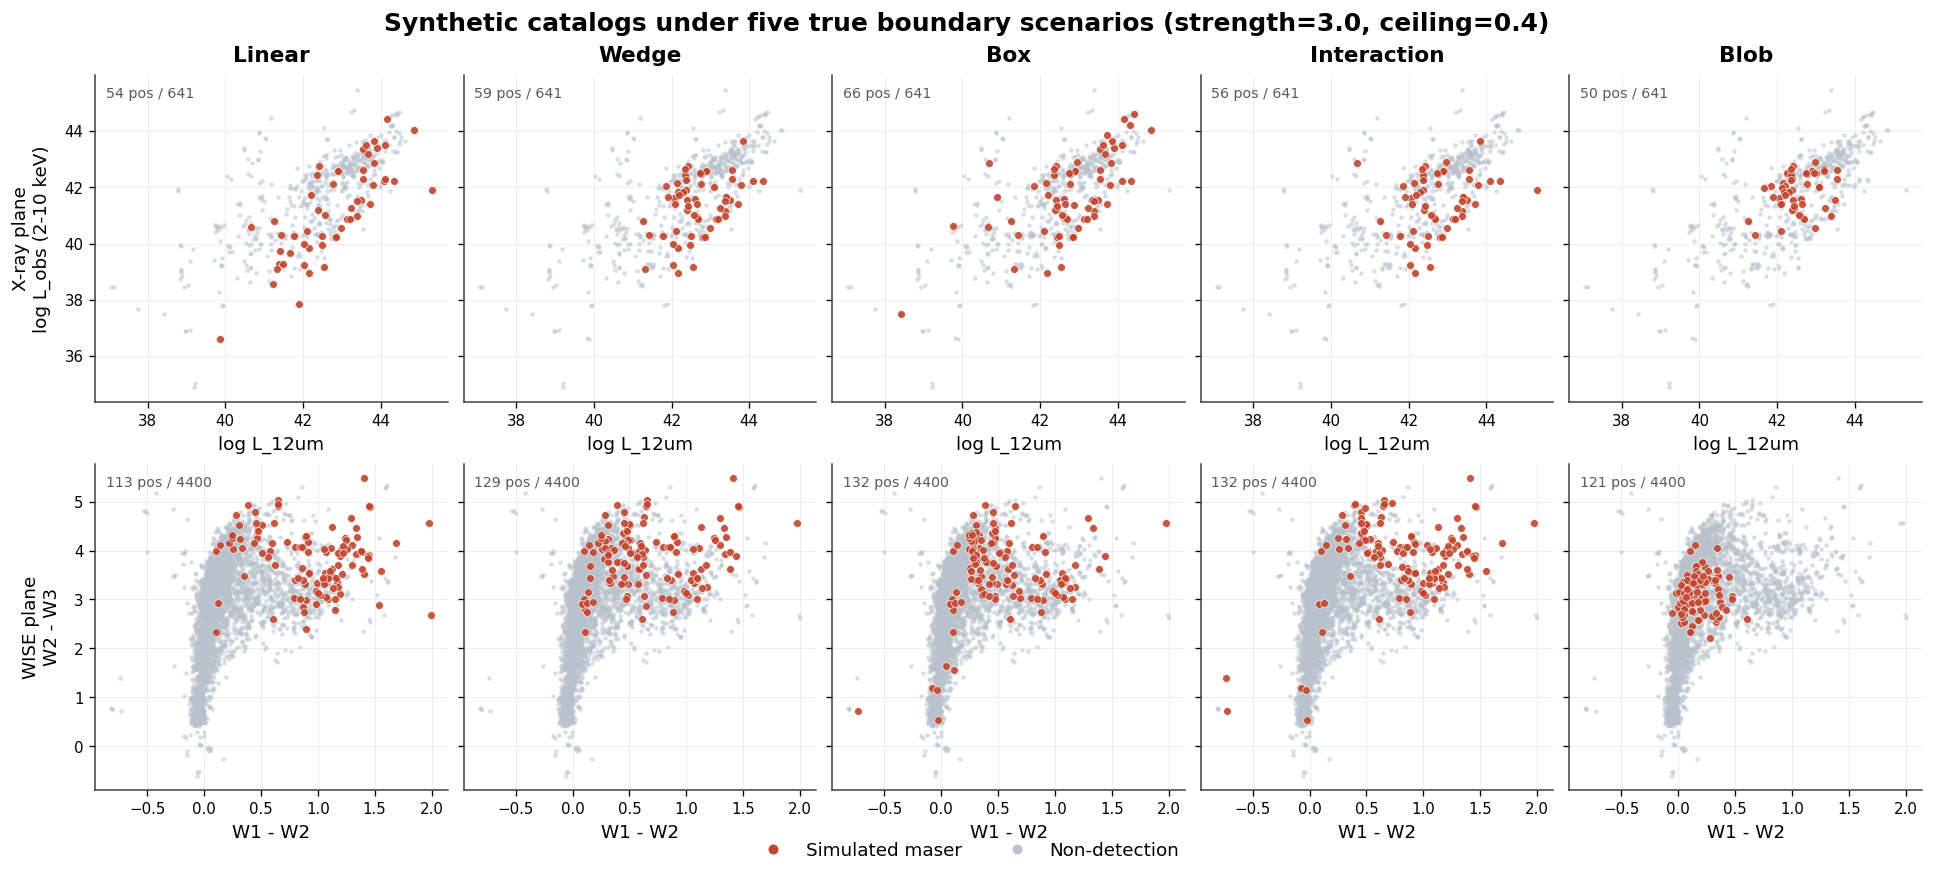

In [68]:
# ---- synthetic scenario panel ----
# strength=STRENGTH is explicit here. Omitting it renders at the library
# default (2.5), which is NOT the data any model is scored on.
SEED_FIG = 5
fig, axes = plt.subplots(2, 5, figsize=(16, 7.0), constrained_layout=True)

for r, (plane, (row_title, xlab, ylab)) in enumerate(PLANE_LABELS.items()):
    fx, fy = FEATURES[plane]
    tgt = TARGET[plane]
    xlim = ylim = None
    for c, sc in enumerate(SCENARIOS):
        ax = axes[r, c]
        df = sd.make_dataset(plane, scenario=sc, strength=STRENGTH, seed=SEED_FIG)
        neg, pos = df[df[tgt] == 0], df[df[tgt] == 1]
        ax.scatter(neg[fx], neg[fy], s=7, c=NEG, alpha=.55, lw=0, rasterized=True)
        ax.scatter(pos[fx], pos[fy], s=22, c=POS, alpha=.9, lw=.4,
                   edgecolors="white", rasterized=True)
        if r == 0:
            ax.set_title(sc.capitalize(), pad=8, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{row_title}\n{ylab}", labelpad=8)
        else:
            ax.tick_params(labelleft=False)
        ax.set_xlabel(xlab)
        ax.grid(True, lw=.4, color="#E6E6E6"); ax.set_axisbelow(True)
        ax.annotate(f"{len(pos)} pos / {len(df)}", xy=(.03, .93),
                    xycoords="axes fraction", fontsize=8.5, color="#5A5A5A")
        if c == 0:
            xlim, ylim = ax.get_xlim(), ax.get_ylim()
        else:
            ax.set_xlim(xlim); ax.set_ylim(ylim)

handles = [Line2D([], [], marker="o", ls="", ms=7, mfc=POS, mec="white", label="Simulated maser"),
           Line2D([], [], marker="o", ls="", ms=6, mfc=NEG, mec="none", label="Non-detection")]
fig.legend(handles=handles, loc="lower center", ncol=2,
           bbox_to_anchor=(.5, -.035), fontsize=11)
fig.suptitle(f"Synthetic catalogs under five true boundary scenarios "
             f"(strength={STRENGTH}, ceiling=0.4)",
             fontsize=15, fontweight="bold")
_save(fig, "scenario_panel"); plt.show()

saved poster_figs/real_context.png


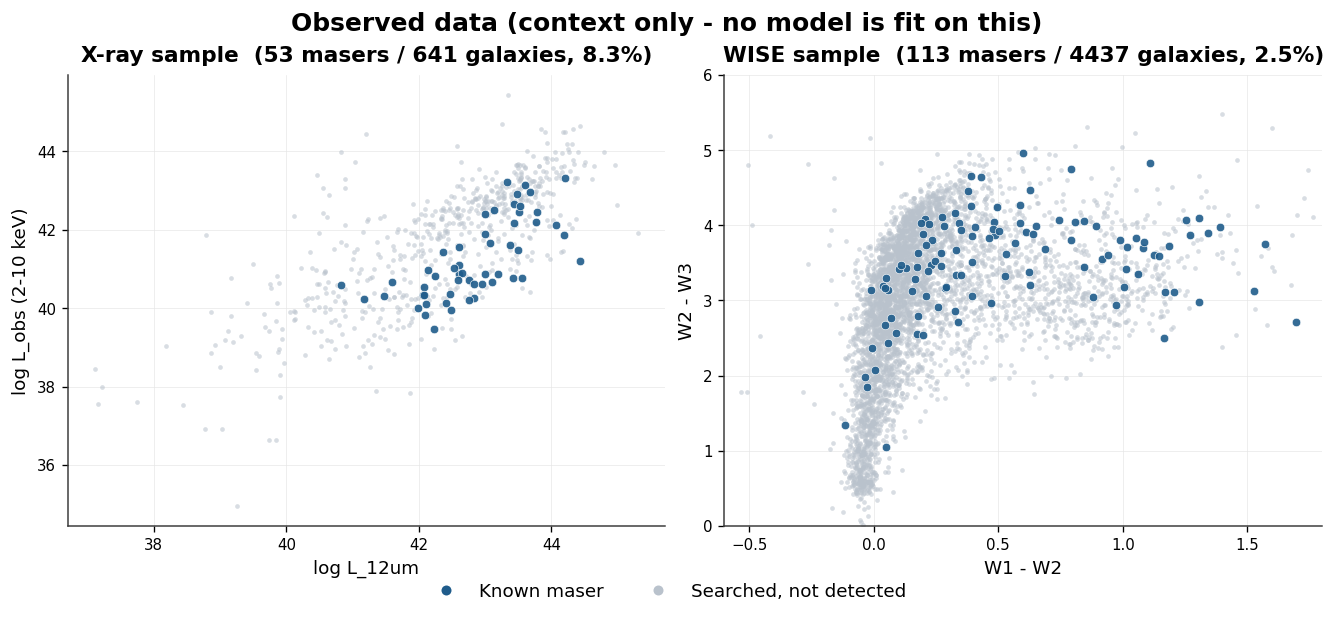

In [69]:
# ---- real catalogs: CONTEXT ONLY ----
# No model in this notebook is fit on real data. This figure exists to show
# why the synthetic prevalence and overlap were chosen. Set to False to skip.
SHOW_REAL_CONTEXT = True

if SHOW_REAL_CONTEXT:
    from maser_data import load_xray_sample, load_wise
    real = {
        "xray": (load_xray_sample(), "X-ray sample", *PLANE_LABELS["xray"][1:]),
        "wise": (load_wise(),        "WISE sample",  *PLANE_LABELS["wise"][1:]),
    }
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
    for ax, (plane, (df, title, xlab, ylab)) in zip(axes, real.items()):
        fx, fy = FEATURES[plane]
        tgt = TARGET[plane]
        d = df.dropna(subset=[fx, fy, tgt])
        neg, pos = d[d[tgt] == 0], d[d[tgt] == 1]
        ax.scatter(neg[fx], neg[fy], s=8, c=NEG, alpha=.55, lw=0, rasterized=True)
        ax.scatter(pos[fx], pos[fy], s=26, c=REAL_POS, alpha=.9, lw=.4,
                   edgecolors="white", rasterized=True)
        ax.set_title(f"{title}  ({len(pos)} masers / {len(d)} galaxies, "
                     f"{100*len(pos)/len(d):.1f}%)", pad=8, fontweight="bold")
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.grid(True, lw=.4, color="#E6E6E6"); ax.set_axisbelow(True)
    axes[1].set_xlim(-0.6, 1.8); axes[1].set_ylim(0, 6)
    handles = [Line2D([], [], marker="o", ls="", ms=7, mfc=REAL_POS, mec="white", label="Known maser"),
               Line2D([], [], marker="o", ls="", ms=6, mfc=NEG, mec="none", label="Searched, not detected")]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               bbox_to_anchor=(.5, -.06), fontsize=11)
    fig.suptitle("Observed data (context only - no model is fit on this)",
                 fontsize=15, fontweight="bold")
    _save(fig, "real_context"); plt.show()

## 6. Tuned-model evaluation

All three planes, frozen lineups, report seeds only.

### 6.1 Synthetic X-ray

In [70]:
xray_results = run_grid(TUNED["xray"], xray_dataset_fn, XRAY_FEATS, XRAY_TGT)

  4 models x 5 scenarios x 40 seeds on 200 shared catalogs in 364s


In [71]:
show_metric(xray_results, "prec_at_n")
show_metric(xray_results, "mse_vs_truth")

# the comparison that can actually be claimed at this noise level
show_paired(xray_results, "prec_at_n")
show_paired(xray_results, "mse_vs_truth")

show_metric(xray_results, "brier")
show_metric(xray_results, "pr_auc")
show_metric(xray_results, "auc")

print(f"X-ray, top-{N_AT}: masers promised vs delivered")
display(promise_topn_table(xray_results))
print("\nX-ray, whole sample: promised vs actual vs oracle")
display(promise_total_table(xray_results))

===== prec_at_n (PRIMARY; higher better: True) - mean +/- SE over 40 seeds =====


scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.279 +/- 0.011,0.286 +/- 0.012,0.223 +/- 0.013,0.286 +/- 0.009,0.279 +/- 0.01,0.271 +/- 0.005
rf,0.23 +/- 0.012,0.246 +/- 0.014,0.278 +/- 0.012,0.236 +/- 0.012,0.256 +/- 0.01,0.249 +/- 0.005
hgb,0.228 +/- 0.013,0.23 +/- 0.013,0.264 +/- 0.013,0.233 +/- 0.013,0.228 +/- 0.011,0.237 +/- 0.006
lr_linear,0.285 +/- 0.01,0.219 +/- 0.011,0.188 +/- 0.009,0.228 +/- 0.011,0.024 +/- 0.005,0.189 +/- 0.004


===== mse_vs_truth (PRIMARY; higher better: False) - mean +/- SE over 40 seeds =====


scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.001 +/- 0.0,0.001 +/- 0.0,0.004 +/- 0.0,0.001 +/- 0.0,0.001 +/- 0.0,0.002 +/- 0.0
rf,0.003 +/- 0.0,0.002 +/- 0.0,0.003 +/- 0.0,0.003 +/- 0.0,0.002 +/- 0.0,0.003 +/- 0.0
hgb,0.005 +/- 0.0,0.004 +/- 0.0,0.005 +/- 0.0,0.004 +/- 0.0,0.004 +/- 0.0,0.004 +/- 0.0
lr_linear,0.001 +/- 0.0,0.005 +/- 0.0,0.005 +/- 0.0,0.005 +/- 0.0,0.01 +/- 0.0,0.005 +/- 0.0


===== prec_at_n: paired difference vs lr_linear (higher better: True; * = |t| >= 2) =====


...

scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.766 +/- 0.005,0.795 +/- 0.005,0.644 +/- 0.008,0.779 +/- 0.005,0.84 +/- 0.003,0.765 +/- 0.002
rf,0.701 +/- 0.007,0.767 +/- 0.006,0.651 +/- 0.01,0.748 +/- 0.007,0.813 +/- 0.003,0.736 +/- 0.003
hgb,0.708 +/- 0.007,0.761 +/- 0.006,0.647 +/- 0.01,0.74 +/- 0.007,0.81 +/- 0.004,0.733 +/- 0.003
lr_linear,0.776 +/- 0.005,0.704 +/- 0.006,0.636 +/- 0.008,0.681 +/- 0.008,0.492 +/- 0.006,0.658 +/- 0.003


X-ray, top-50: masers promised vs delivered


linear              wedge                box            \
             promised delivered promised delivered promised delivered   
model                                                                   
hgb              17.0      11.4     17.1      11.5     16.8      13.2   
lr_linear        14.6      14.2     11.0      11.0      8.9       9.4   
lr_quadratic     14.8      14.0     14.7      14.3     11.0      11.2   
rf               12.9      11.5     14.4      12.3     14.6      13.9   

             interaction               blob            
                promised delivered promised delivered  
model                                                  
hgb                 16.7      11.7     17.8      11.4  
lr_linear           10.0      11.4      5.4       1.2  
lr_quadratic        15.4      14.3     13.9      14.0  
rf                  13.9      11.8     14.4      12.8


X-ray, whole sample: promised vs actual vs oracle


scenario,linear,wedge,box,interaction,blob
model,,,,,
hgb,51.5,51.5,52.3,51.9,52.0
lr_linear,52.5,52.2,53.0,52.7,52.6
lr_quadratic,52.4,52.2,53.1,52.6,52.6
rf,51.9,51.9,52.7,52.4,52.5
ACTUAL masers,52.4,52.1,53.0,52.6,52.5
ORACLE (sum p_true),53.2,53.2,53.2,53.2,53.2


### 6.2 Synthetic WISE

In [72]:
wise_results = run_grid(TUNED["wise"], wise_dataset_fn, WISE_FEATS, WISE_TGT)

  4 models x 5 scenarios x 40 seeds on 200 shared catalogs in 574s


In [73]:
show_metric(wise_results, "prec_at_n")
show_metric(wise_results, "mse_vs_truth")

show_paired(wise_results, "prec_at_n")
show_paired(wise_results, "mse_vs_truth")

show_metric(wise_results, "brier")
show_metric(wise_results, "pr_auc")

print(f"WISE, top-{N_AT}: masers promised vs delivered")
display(promise_topn_table(wise_results))
print("\nWISE, whole sample: promised vs actual vs oracle")
display(promise_total_table(wise_results))

===== prec_at_n (PRIMARY; higher better: True) - mean +/- SE over 40 seeds =====


scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.395 +/- 0.01,0.318 +/- 0.011,0.092 +/- 0.006,0.389 +/- 0.011,0.116 +/- 0.006,0.262 +/- 0.004
hgb,0.36 +/- 0.014,0.262 +/- 0.01,0.1 +/- 0.009,0.388 +/- 0.012,0.104 +/- 0.008,0.243 +/- 0.005
rf,0.36 +/- 0.015,0.28 +/- 0.011,0.082 +/- 0.007,0.38 +/- 0.012,0.085 +/- 0.006,0.238 +/- 0.005
lr_linear,0.4 +/- 0.011,0.27 +/- 0.009,0.091 +/- 0.006,0.378 +/- 0.011,0.002 +/- 0.001,0.228 +/- 0.004


===== mse_vs_truth (PRIMARY; higher better: False) - mean +/- SE over 40 seeds =====


scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
hgb,0.001 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.001 +/- 0.0,0.0 +/- 0.0,0.001 +/- 0.0
rf,0.001 +/- 0.0,0.001 +/- 0.0,0.0 +/- 0.0,0.001 +/- 0.0,0.0 +/- 0.0,0.001 +/- 0.0
lr_quadratic,0.001 +/- 0.0,0.001 +/- 0.0,0.001 +/- 0.0,0.002 +/- 0.0,0.0 +/- 0.0,0.001 +/- 0.0
lr_linear,0.001 +/- 0.0,0.001 +/- 0.0,0.001 +/- 0.0,0.002 +/- 0.0,0.001 +/- 0.0,0.001 +/- 0.0


===== prec_at_n: paired difference vs lr_linear (higher better: True; * = |t| >= 2) =====


...

scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.303 +/- 0.006,0.203 +/- 0.004,0.089 +/- 0.002,0.328 +/- 0.006,0.106 +/- 0.002,0.206 +/- 0.002
hgb,0.277 +/- 0.006,0.178 +/- 0.004,0.094 +/- 0.002,0.314 +/- 0.006,0.097 +/- 0.003,0.192 +/- 0.002
rf,0.278 +/- 0.006,0.183 +/- 0.004,0.091 +/- 0.002,0.308 +/- 0.006,0.088 +/- 0.002,0.189 +/- 0.002
lr_linear,0.308 +/- 0.006,0.173 +/- 0.004,0.084 +/- 0.002,0.311 +/- 0.006,0.03 +/- 0.0,0.181 +/- 0.002


WISE, top-50: masers promised vs delivered


linear              wedge                box            \
             promised delivered promised delivered promised delivered   
model                                                                   
hgb              23.5      18.0     16.4      13.1      9.1       5.0   
lr_linear        31.2      20.0     18.8      13.5     10.8       4.6   
lr_quadratic     26.1      19.8     18.7      15.9      9.0       4.6   
rf               18.3      18.0     13.1      14.0      6.8       4.1   

             interaction               blob            
                promised delivered promised delivered  
model                                                  
hgb                 24.5      19.4      7.6       5.2  
lr_linear           28.6      18.9      2.8       0.1  
lr_quadratic        30.5      19.4      4.2       5.8  
rf                  18.6      19.0      3.8       4.3


WISE, whole sample: promised vs actual vs oracle


scenario,linear,wedge,box,interaction,blob
model,,,,,
hgb,130.2,129.5,131.9,130.4,128.6
lr_linear,130.8,129.8,132.2,131.4,129.0
lr_quadratic,130.7,129.8,132.2,131.3,128.8
rf,130.1,129.1,131.9,129.9,128.8
ACTUAL masers,130.4,129.6,132.1,130.9,128.8
ORACLE (sum p_true),132.0,132.0,132.0,132.0,132.0


### 6.3 Synthetic fused (X-ray + WISE)

In [74]:
fused_results = run_grid(TUNED["fused"], fused_dataset_fn, FUSED_FEATS, FUSED_TGT)

  4 models x 5 scenarios x 40 seeds on 200 shared catalogs in 408s


In [75]:
show_metric(fused_results, "prec_at_n")
show_metric(fused_results, "mse_vs_truth")

show_paired(fused_results, "prec_at_n")
show_paired(fused_results, "mse_vs_truth")

show_metric(fused_results, "brier")
show_metric(fused_results, "pr_auc")

print(f"Fused, top-{N_AT}: masers promised vs delivered")
display(promise_topn_table(fused_results))
print("\nFused, whole sample: promised vs actual vs oracle")
display(promise_total_table(fused_results))

===== prec_at_n (PRIMARY; higher better: True) - mean +/- SE over 40 seeds =====


scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.351 +/- 0.012,0.342 +/- 0.011,0.323 +/- 0.012,0.344 +/- 0.01,0.322 +/- 0.011,0.336 +/- 0.005
lr_linear,0.364 +/- 0.01,0.341 +/- 0.01,0.354 +/- 0.01,0.32 +/- 0.009,0.241 +/- 0.011,0.324 +/- 0.004
rf,0.334 +/- 0.01,0.324 +/- 0.012,0.31 +/- 0.009,0.324 +/- 0.011,0.294 +/- 0.012,0.317 +/- 0.005
hgb,0.31 +/- 0.012,0.308 +/- 0.011,0.294 +/- 0.011,0.32 +/- 0.011,0.321 +/- 0.013,0.311 +/- 0.005


===== mse_vs_truth (PRIMARY; higher better: False) - mean +/- SE over 40 seeds =====


scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.006 +/- 0.0,0.006 +/- 0.0,0.008 +/- 0.0,0.006 +/- 0.0,0.006 +/- 0.0,0.006 +/- 0.0
rf,0.006 +/- 0.0,0.006 +/- 0.0,0.007 +/- 0.0,0.006 +/- 0.0,0.007 +/- 0.0,0.006 +/- 0.0
lr_linear,0.004 +/- 0.0,0.005 +/- 0.0,0.006 +/- 0.0,0.007 +/- 0.0,0.011 +/- 0.0,0.007 +/- 0.0
hgb,0.01 +/- 0.0,0.01 +/- 0.0,0.011 +/- 0.0,0.011 +/- 0.0,0.01 +/- 0.0,0.01 +/- 0.0


===== prec_at_n: paired difference vs lr_linear (higher better: True; * = |t| >= 2) =====


...

scenario,linear,wedge,box,interaction,blob,MEAN
model,,,,,,
lr_quadratic,0.303 +/- 0.009,0.313 +/- 0.008,0.268 +/- 0.008,0.313 +/- 0.009,0.3 +/- 0.009,0.299 +/- 0.004
lr_linear,0.33 +/- 0.008,0.308 +/- 0.008,0.302 +/- 0.007,0.284 +/- 0.008,0.212 +/- 0.006,0.287 +/- 0.003
rf,0.29 +/- 0.008,0.295 +/- 0.009,0.261 +/- 0.008,0.286 +/- 0.009,0.27 +/- 0.009,0.28 +/- 0.004
hgb,0.272 +/- 0.008,0.288 +/- 0.01,0.254 +/- 0.008,0.286 +/- 0.01,0.296 +/- 0.011,0.279 +/- 0.004


Fused, top-50: masers promised vs delivered


linear              wedge                box            \
             promised delivered promised delivered promised delivered   
model                                                                   
hgb              23.8      15.5     23.7      15.4     22.4      14.7   
lr_linear        20.7      18.2     19.2      17.0     18.2      17.7   
lr_quadratic     17.6      17.6     17.1      17.1     15.9      16.2   
rf               19.3      16.7     18.3      16.2     17.5      15.5   

             interaction               blob            
                promised delivered promised delivered  
model                                                  
hgb                 23.2      16.0     23.3      16.0  
lr_linear           17.9      16.0     14.5      12.0  
lr_quadratic        17.1      17.2     13.5      16.1  
rf                  18.2      16.2     15.3      14.7


Fused, whole sample: promised vs actual vs oracle


scenario,linear,wedge,box,interaction,blob
model,,,,,
hgb,47.0,46.7,46.7,45.7,47.9
lr_linear,50.6,50.8,50.4,50.4,51.7
lr_quadratic,50.4,50.6,50.3,50.1,51.5
rf,49.9,50.2,49.6,49.9,51.3
ACTUAL masers,50.4,50.5,50.3,50.1,51.2
ORACLE (sum p_true),50.0,50.0,50.0,50.0,50.0


## 7. How much unique signal must WISE carry before fusion pays?

The generator's `wise_signal` knob controls how much X-ray-orthogonal information the WISE colours carry: 0 means fully redundant. For each value, the fused winner is evaluated twice on the **same** catalog build, once with all four features and once restricted to the two X-ray columns, so the gap between the curves is the value of fusion itself rather than a modelling difference.

Runs on `WS_SEEDS` (10 seeds) rather than the full report set, because the sweep is ten times the work of a single evaluation.

In [76]:
WS_GRID     = [0.0, 0.5, 1.0, 1.5, 2.0]
WS_FEATSETS = {"xray_only": FUSED_FEATS[:2], "xray+wise": FUSED_FEATS}
WS_MODEL    = "hgb"        # point at the fused winner

def ws_dataset_fn(scenario, ws):
    return lambda seed: sd.make_fused_dataset(scenario=scenario, wise_signal=ws,
                                              strength=STRENGTH, seed=seed)

def _ws_one_seed(build, dataset_fn, featsets, tgt, seed):
    """Both feature sets on one shared catalog build. Top level for joblib."""
    d = dataset_fn(seed)
    return {fname: _metrics_on(build, d, feats, tgt, seed)
            for fname, feats in featsets.items()}

build = TUNED["fused"][WS_MODEL]
seeds = list(WS_SEEDS)
tasks = [(ws, sc, s) for ws in WS_GRID for sc in SCENARIOS for s in seeds]

In [77]:
t0 = time.time()
_res = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_ws_one_seed)(build, ws_dataset_fn(sc, ws),
                          WS_FEATSETS, FUSED_TGT, s)
    for ws, sc, s in tasks
)
ws_sweep = pd.DataFrame([
    {"model": WS_MODEL, "wise_signal": ws, "features": fname, "scenario": sc, **m}
    for (ws, sc, _), per_fs in zip(tasks, _res)
    for fname, m in per_fs.items()
])
print(f"  {len(tasks)} shared catalogs x {len(WS_FEATSETS)} feature sets "
      f"in {time.time() - t0:.0f}s")

  250 shared catalogs x 2 feature sets in 186s


saved poster_figs/wise_signal_sweep.png


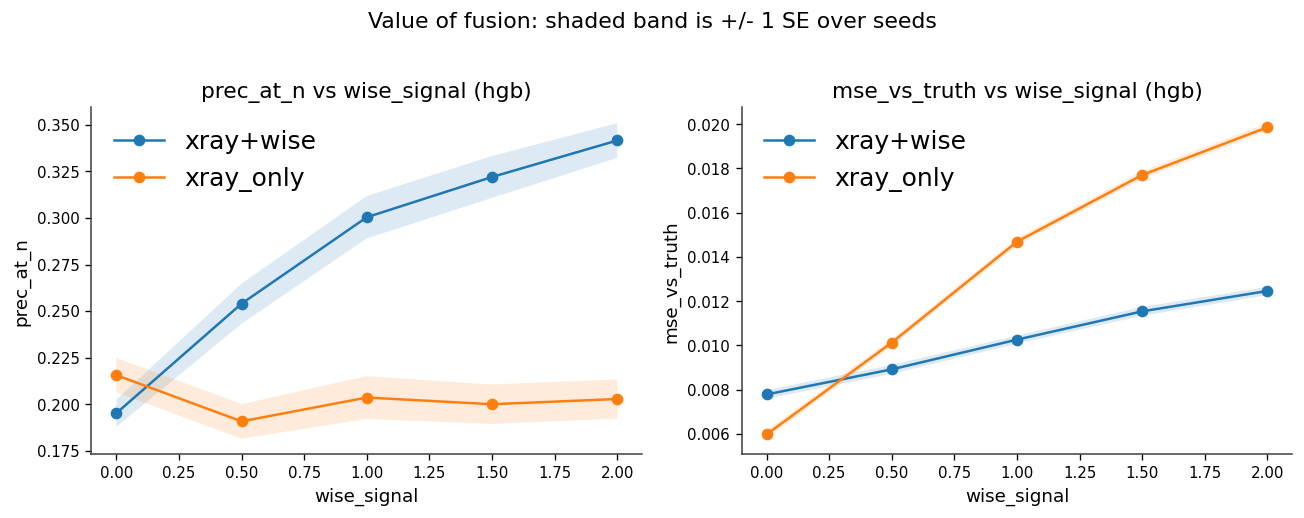

===== prec_at_n: paired gain from adding WISE features (higher better: True) =====


,gain,se,t
wise_signal,,,
0.0,-0.0204,0.0067,-3.04
0.5,0.0632,0.0083,7.61
1.0,0.0968,0.0096,10.08
1.5,0.1220,0.0085,14.35
2.0,0.1388,0.0097,14.31


===== mse_vs_truth: paired gain from adding WISE features (higher better: False) =====


,gain,se,t
wise_signal,,,
0.0,0.0018,0.0001,18.0
0.5,-0.0012,0.0002,-6.0
1.0,-0.0044,0.0002,-22.0
1.5,-0.0062,0.0002,-31.0
2.0,-0.0074,0.0002,-37.0


In [78]:
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(11, 4.2))
for ax, m in zip(axes, PRIMARY_METRICS):
    for fname, g in ws_sweep.groupby("features"):
        gg   = g.groupby("wise_signal")[m]
        mean = gg.mean()
        se   = gg.std(ddof=1) / np.sqrt(gg.count())
        ax.plot(mean.index, mean.values, marker="o", label=fname)
        ax.fill_between(mean.index, mean - se, mean + se, alpha=0.15)
    ax.set_xlabel("wise_signal"); ax.set_ylabel(m)
    ax.set_title(f"{m} vs wise_signal ({WS_MODEL})")
    ax.legend()
fig.suptitle("Value of fusion: shaded band is +/- 1 SE over seeds", y=1.02)
plt.tight_layout(); _save(fig, "wise_signal_sweep"); plt.show()

# paired: same catalogs, same model, features are the only thing that changes
for m in PRIMARY_METRICS:
    base = (ws_sweep[ws_sweep["features"] == "xray_only"]
            .set_index(["wise_signal", "scenario", "seed"])[m])
    d = (ws_sweep[ws_sweep["features"] == "xray+wise"]
         .set_index(["wise_signal", "scenario", "seed"])[m] - base)
    g = d.groupby("wise_signal")
    out = pd.DataFrame({"gain": g.mean().round(4),
                        "se": (g.std(ddof=1) / np.sqrt(g.count())).round(4)})
    out["t"] = (out["gain"] / out["se"]).round(2)
    print(f"===== {m}: paired gain from adding WISE features "
          f"(higher better: {HIGHER_BETTER[m]}) =====")
    display(out)

## 8. Cross-plane summary

prec@N is comparable **within** a plane only: n and prevalence differ across planes.

In [79]:
PLANE_ORDER = ["synth_xray", "synth_wise"]
ALL_RESULTS = {"synth_xray": xray_results,
               "synth_wise": wise_results}

summary = pd.concat(
    {k: v.groupby("model")[METRICS].mean() for k, v in ALL_RESULTS.items()},
    names=["plane", "model"]).round(3)
print("Scenario-mean of every metric, all planes:")
display(summary)

for m in PRIMARY_METRICS:
    t = summary[m].unstack("plane")[PLANE_ORDER]
    print(f"\n===== {m} by plane (higher better: {HIGHER_BETTER[m]}) =====")
    display(t.sort_values("synth_xray", ascending=not HIGHER_BETTER[m]).round(3))

# paired gain vs the linear baseline, pooled across scenarios, per plane
for m in PRIMARY_METRICS:
    rows = []
    for plane, res in ALL_RESULTS.items():
        t = paired_table(res, m)
        for name, g in t.groupby("model"):
            # pool scenarios by inverse-variance-free simple mean; SE combined
            rows.append({"plane": plane, "model": name,
                         "diff": g["diff"].mean(),
                         "se": np.sqrt((g["se"] ** 2).sum()) / len(g)})
    out = pd.DataFrame(rows)
    out["t"] = out["diff"] / out["se"]
    print(f"===== {m}: paired difference vs {BASELINE_MODEL}, "
          f"pooled over scenarios (higher better: {HIGHER_BETTER[m]}) =====")
    display(out.pivot(index="model", columns="plane", values=["diff", "se"]).round(3))

Scenario-mean of every metric, all planes:


prec_at_n  mse_vs_truth  brier  pr_auc    auc
plane      model                                                      
synth_xray hgb               0.237         0.004  0.071   0.204  0.733
           lr_linear         0.189         0.005  0.072   0.168  0.658
           lr_quadratic      0.271         0.002  0.069   0.231  0.765
           rf                0.249         0.003  0.070   0.210  0.736
synth_wise hgb               0.243         0.001  0.026   0.192  0.863
           lr_linear         0.228         0.001  0.026   0.181  0.804
           lr_quadratic      0.262         0.001  0.026   0.206  0.869
           rf                0.238         0.001  0.026   0.189  0.860


===== prec_at_n by plane (higher better: True) =====


plane,synth_xray,synth_wise
model,,
lr_quadratic,0.271,0.262
rf,0.249,0.238
hgb,0.237,0.243
lr_linear,0.189,0.228



===== mse_vs_truth by plane (higher better: False) =====


plane,synth_xray,synth_wise
model,,
lr_quadratic,0.002,0.001
rf,0.003,0.001
hgb,0.004,0.001
lr_linear,0.005,0.001


===== prec_at_n: paired difference vs lr_linear, pooled over scenarios (higher better: True) =====


diff                    se           
plane        synth_wise synth_xray synth_wise synth_xray
model                                                   
hgb               0.015      0.048      0.004      0.005
lr_quadratic      0.034      0.082      0.003      0.004
rf                0.009      0.061      0.004      0.005

===== mse_vs_truth: paired difference vs lr_linear, pooled over scenarios (higher better: False) =====


diff                    se           
plane        synth_wise synth_xray synth_wise synth_xray
model                                                   
hgb              -0.001     -0.001        0.0        0.0
lr_quadratic     -0.001     -0.003        0.0        0.0
rf               -0.001     -0.002        0.0        0.0

## 9. Poster figures

Error bars are **+/- 1 SE over report seeds**. Dotted line is the synthetic catalog's own positive rate, which is what a random ranking scores in expectation.

Real-survey context for captions, not plotted: Kuo et al. 2018 GBT sample, 2.7% megamasers and 0.9% disk masers; Kuo et al. 2020 X-ray sample, 8.3% megamasers (53/641) and 3.7% disk (24/641).

In [80]:
MODEL_COLORS = {"lr_linear": "#4C72B0", "lr_quadratic": "#55A868",
                "rf": "#C44E52", "hgb": "#8172B3"}
PROMISE_COLOR, DELIVER_COLOR = "#B0B0B0", "#2A6F97"
RAND_COLOR, RAND_STYLE, HALF = "#333333", (0, (1.6, 1.6)), 0.44

plt.rcParams.update({"font.size": 17, "axes.titlesize": 18, "axes.labelsize": 17,
                     "xtick.labelsize": 15, "ytick.labelsize": 15,
                     "legend.fontsize": 15})

# Prevalence baselines come straight from the evaluation results
# (actual_total / n per seed) - no need to regenerate 600 catalogs.
PREV = {k: (v["actual_total"] / v["n"]).groupby(v["scenario"]).mean()
            .reindex(SCENARIOS)
        for k, v in ALL_RESULTS.items()}
print("synthetic prevalence by scenario (real surveys run 2.7-8.3%):")
display(pd.DataFrame(PREV).round(4))

def _order(res):
    present = [m for m in MODEL_ORDER if m in res["model"].unique() and m != "hgb"]
    return present + [m for m in res["model"].unique() if m not in present and m != "hgb"]

def _mean_se(res, metric):
    g = res.groupby(["model", "scenario"])[metric]
    return (g.mean().unstack("scenario")[SCENARIOS],
            (g.std(ddof=1) / np.sqrt(g.count())).unstack("scenario")[SCENARIOS])

def _bar_x(i, j, n):
    w = 0.8 / n
    return i + j * w - 0.4 + w / 2, w

def _label_bars(ax, xs, h, e, fmt="{:.2f}", fontsize=7.5, rot=90):
    pad = 0.015 * (ax.get_ylim()[1] - ax.get_ylim()[0])
    for x, hh, ee in zip(xs, h, e):
        ee = 0.0 if not np.isfinite(ee) else ee
        ax.text(x, hh + ee + pad, fmt.format(hh), ha="center", va="bottom",
                fontsize=fontsize, rotation=rot)

def _draw_baselines(ax, level, x):
    for i, sc in enumerate(SCENARIOS):
        ax.hlines(level[sc], x[i] - HALF, x[i] + HALF, colors=RAND_COLOR,
                  linestyles=RAND_STYLE, linewidth=1.8, zorder=6)

def _baseline_handle(label):
    return [plt.Line2D([0], [0], color=RAND_COLOR, linestyle=RAND_STYLE,
                       linewidth=1.8, label=label)]

def _legend_below(ax, extra, ncol=3):
    ax.legend(handles=ax.get_legend_handles_labels()[0] + extra,
              loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=ncol,
              fontsize=10, frameon=False, handlelength=1.8, columnspacing=1.4)

synthetic prevalence by scenario (real surveys run 2.7-8.3%):


,synth_xray,synth_wise
scenario,,
linear,0.0818,0.0296
wedge,0.0813,0.0294
box,0.0827,0.0300
interaction,0.0820,0.0298
blob,0.0819,0.0293


In [81]:
def plot_prec_by_scenario(res, plane_label, tag, prev):
    models = _order(res)
    t, e = _mean_se(res, "prec_at_n")
    t, e = t.loc[models].T, e.loc[models].T
    x = np.arange(len(SCENARIOS))
    fig, ax = plt.subplots(figsize=(9, 6.2))
    for j, mdl in enumerate(models):
        xs, w = _bar_x(x, j, len(models))
        ax.bar(xs, t[mdl].values, w, yerr=e[mdl].values, capsize=2, label=mdl,
               color=MODEL_COLORS.get(mdl, "#777"), edgecolor="black", linewidth=0.4)
    ax.set_ylim(0, min(1.0, float(np.nanmax(t.values + e.values)) * 1.30))
    for j, mdl in enumerate(models):
        xs, _ = _bar_x(x, j, len(models))
        _label_bars(ax, xs, t[mdl].values, e[mdl].values)
    _draw_baselines(ax, prev, x)
    ax.set_xticks(x); ax.set_xticklabels(SCENARIOS)
    ax.set_ylabel(f"precision@{N_AT}")
    ax.set_title(f"{plane_label}: precision@{N_AT} by scenario\n"
                 f"(error bars = +/- 1 SE over {res['seed'].nunique()} seeds)")
    _legend_below(ax, _baseline_handle("random ranking (catalog rate)"))
    fig.tight_layout(); fig.subplots_adjust(bottom=0.26)
    _save(fig, f"{tag}_prec_by_scenario"); plt.show()

In [82]:
def plot_pvd_by_scenario(res, plane_label, tag, prev):
    models = _order(res)
    pm, pe = _mean_se(res, "promised_at_n")
    dm, de = _mean_se(res, "delivered_at_n")
    pm, pe, dm, de = (df.loc[models].T for df in (pm, pe, dm, de))
    x = np.arange(len(models)); w = 0.38
    rand_yield = {sc: N_AT * prev[sc] for sc in SCENARIOS}
    ceiling = float(np.nanmax([np.nanmax(pm.values + pe.values),
                              np.nanmax(dm.values + de.values),
                              max(rand_yield.values())]))
    fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(16, 5.2), sharey=True)
    for ax, sc in zip(axes, SCENARIOS):
        ax.bar(x - w/2, pm.loc[sc].values, w, yerr=pe.loc[sc].values, capsize=2,
               color=PROMISE_COLOR, edgecolor="black", linewidth=0.4)
        ax.bar(x + w/2, dm.loc[sc].values, w, yerr=de.loc[sc].values, capsize=2,
               color=DELIVER_COLOR, edgecolor="black", linewidth=0.4)
        ax.set_ylim(0, ceiling * 1.30)
        _label_bars(ax, x - w/2, pm.loc[sc].values, pe.loc[sc].values, fmt="{:.1f}", fontsize=7)
        _label_bars(ax, x + w/2, dm.loc[sc].values, de.loc[sc].values, fmt="{:.1f}", fontsize=7)
        ax.axhline(rand_yield[sc], color=RAND_COLOR, linestyle=RAND_STYLE,
                   linewidth=1.8, zorder=6)
        ax.set_title(sc); ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=90, fontsize=9)
    axes[0].set_ylabel(f"masers in top-{N_AT}")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PROMISE_COLOR),
               plt.Rectangle((0, 0), 1, 1, color=DELIVER_COLOR)]
    bl = _baseline_handle(f"random {N_AT} targets (catalog rate)")
    fig.legend(handles + bl, ["promised", "delivered", bl[0].get_label()],
               loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.10), fontsize=10)
    fig.suptitle(f"{plane_label}: promised vs delivered in top-{N_AT} "
                 f"(error bars = +/- 1 SE over seeds)", y=1.02)
    plt.tight_layout(); _save(fig, f"{tag}_pvd_by_scenario"); plt.show()

In [83]:
def plot_brier_skill_by_scenario(res, plane_label, tag, prev):
    models = _order(res)
    t, e = _mean_se(res, "brier")
    t, e = t.loc[models].T, e.loc[models].T
    null = pd.Series({sc: prev[sc] * (1 - prev[sc]) for sc in SCENARIOS}).reindex(SCENARIOS)
    t = 1 - t.div(null, axis=0)
    e = e.div(null, axis=0)
    x = np.arange(len(SCENARIOS))
    fig, ax = plt.subplots(figsize=(9, 6.2))
    for j, mdl in enumerate(models):
        xs, w = _bar_x(x, j, len(models))
        ax.bar(xs, t[mdl].values, w, yerr=e[mdl].values, capsize=2, label=mdl,
               color=MODEL_COLORS.get(mdl, "#777"), edgecolor="black", linewidth=0.4)
    lo = float(np.nanmin(np.minimum(t.values - e.values, 0)))
    hi = float(np.nanmax(t.values + e.values))
    ax.set_ylim(min(0, lo * 1.15), hi * 1.30)
    for j, mdl in enumerate(models):
        xs, _ = _bar_x(x, j, len(models))
        _label_bars(ax, xs, t[mdl].values, e[mdl].values, fmt="{:.2f}")
    ax.axhline(0, color=RAND_COLOR, linestyle=RAND_STYLE, linewidth=1.8, zorder=6)
    ax.set_xticks(x); ax.set_xticklabels(SCENARIOS)
    ax.set_ylabel("Brier skill score")
    ax.set_title(f"{plane_label}: Brier skill score by scenario\n"
                 "higher is better; 0 = predicting the base rate for every galaxy")
    _legend_below(ax, _baseline_handle("no-skill baseline (BSS = 0)"))
    fig.tight_layout(); fig.subplots_adjust(bottom=0.26)
    _save(fig, f"{tag}_brier_skill_by_scenario"); plt.show()

In [84]:
def plot_pvd_calibration(res, plane_label, tag):
    models = _order(res)
    markers = ["o", "s", "^", "D", "v"]
    a = res.groupby(["model", "scenario"])[["promised_at_n", "delivered_at_n"]].mean()
    fig, ax = plt.subplots(figsize=(6, 6))
    allv = []
    for mdl in models:
        for k, sc in enumerate(SCENARIOS):
            p, d = a.loc[(mdl, sc), "promised_at_n"], a.loc[(mdl, sc), "delivered_at_n"]
            ax.scatter(p, d, color=MODEL_COLORS.get(mdl, "#777"),
                       marker=markers[k % len(markers)], s=80,
                       edgecolor="black", linewidth=0.4, zorder=3)
            allv += [p, d]
    lo, hi = min(allv) * 0.9, max(allv) * 1.05
    ax.plot([lo, hi], [lo, hi], "--", color="gray", label="promise met (y = x)")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"promised masers (top-{N_AT})")
    ax.set_ylabel(f"delivered masers (top-{N_AT})")
    ax.set_title(f"{plane_label}: calibration of the promise\n(below the line = over-promised)")
    mh = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=MODEL_COLORS.get(m, "#777"),
                     markersize=10, label=m) for m in models]
    sh = [plt.Line2D([0], [0], marker=markers[i], color="gray", linestyle="",
                     markersize=8, label=sc) for i, sc in enumerate(SCENARIOS)]
    ax.legend(handles=mh + sh, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.tight_layout(); _save(fig, f"{tag}_pvd_calibration"); plt.show()

saved poster_figs/xray_prec_by_scenario.png


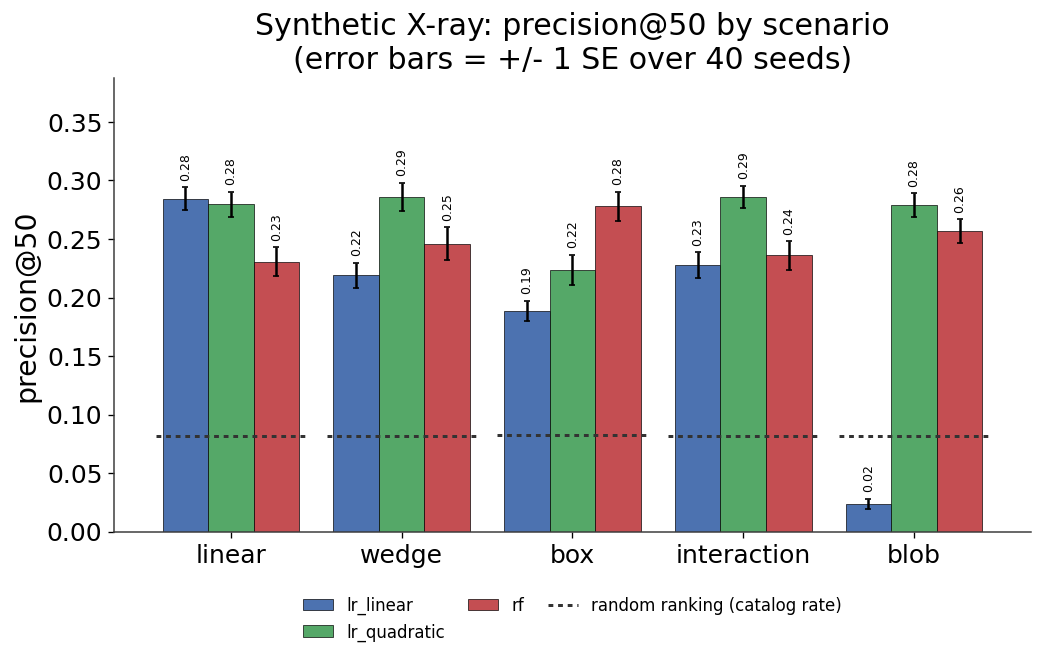

saved poster_figs/xray_pvd_by_scenario.png


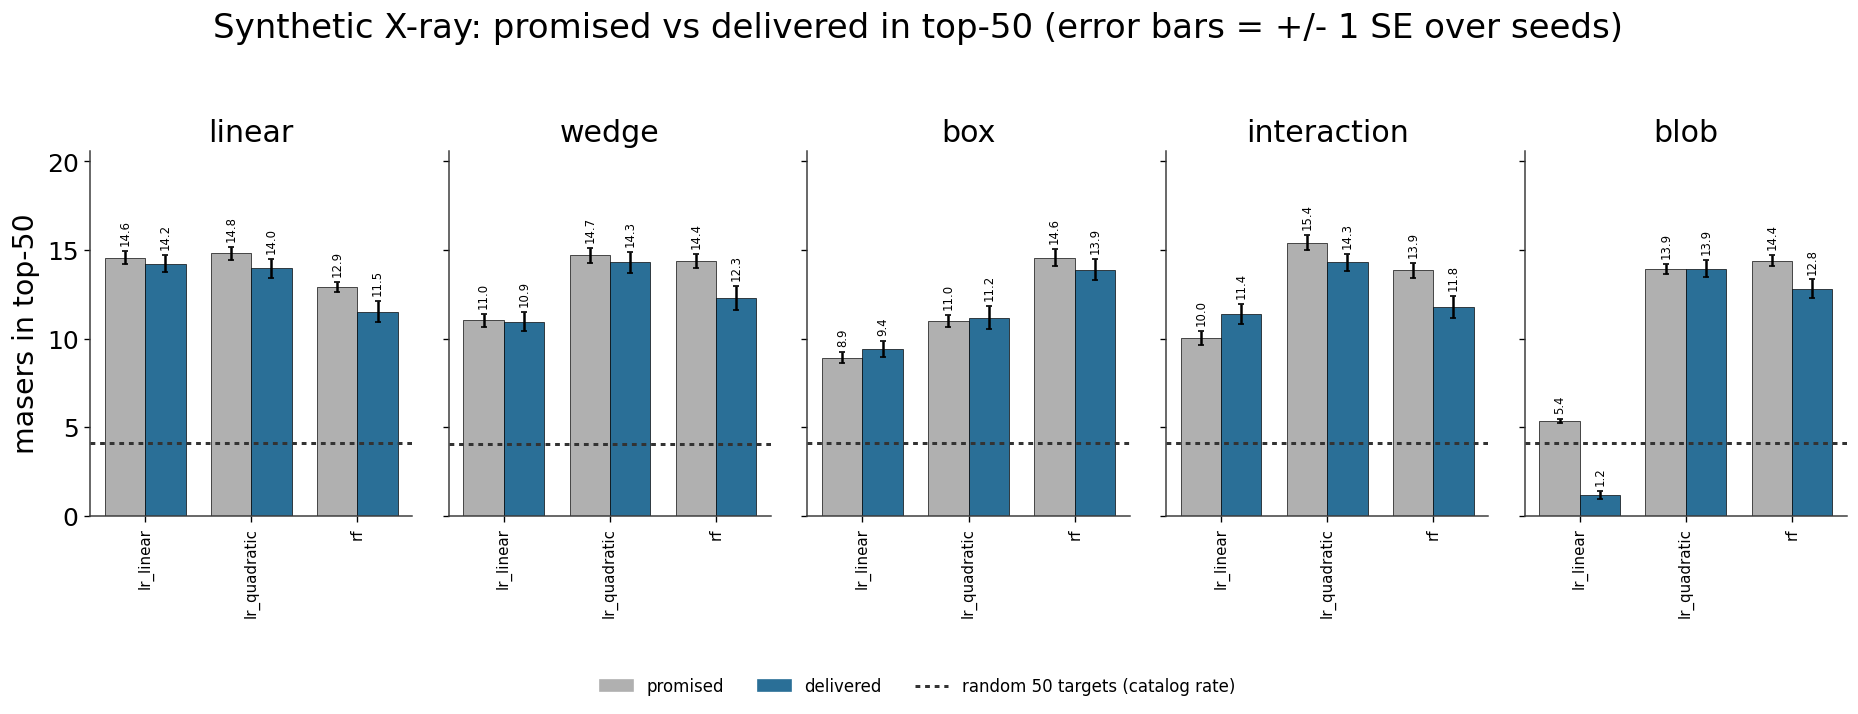

saved poster_figs/xray_brier_skill_by_scenario.png


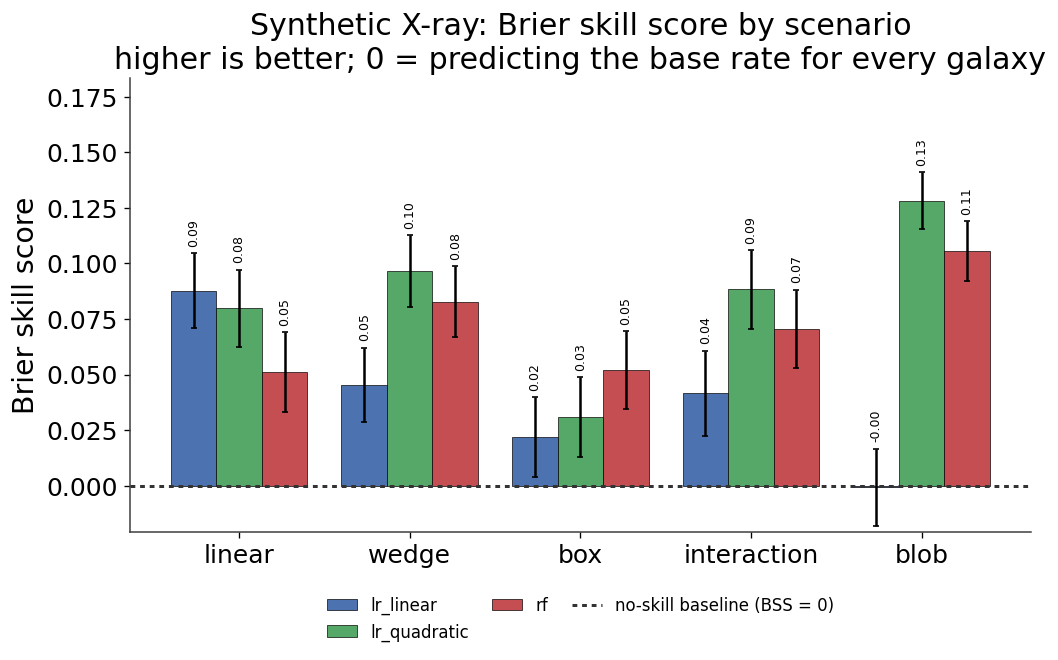

saved poster_figs/xray_pvd_calibration.png


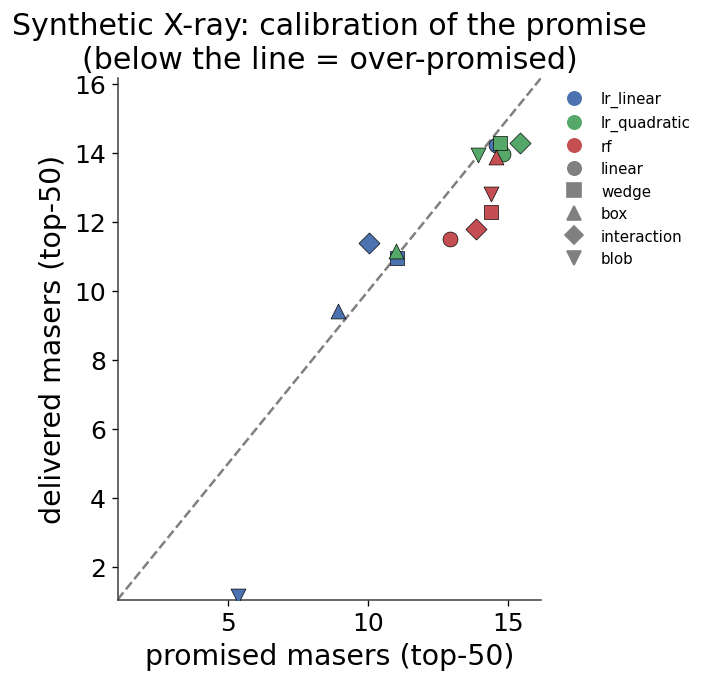

saved poster_figs/wise_prec_by_scenario.png


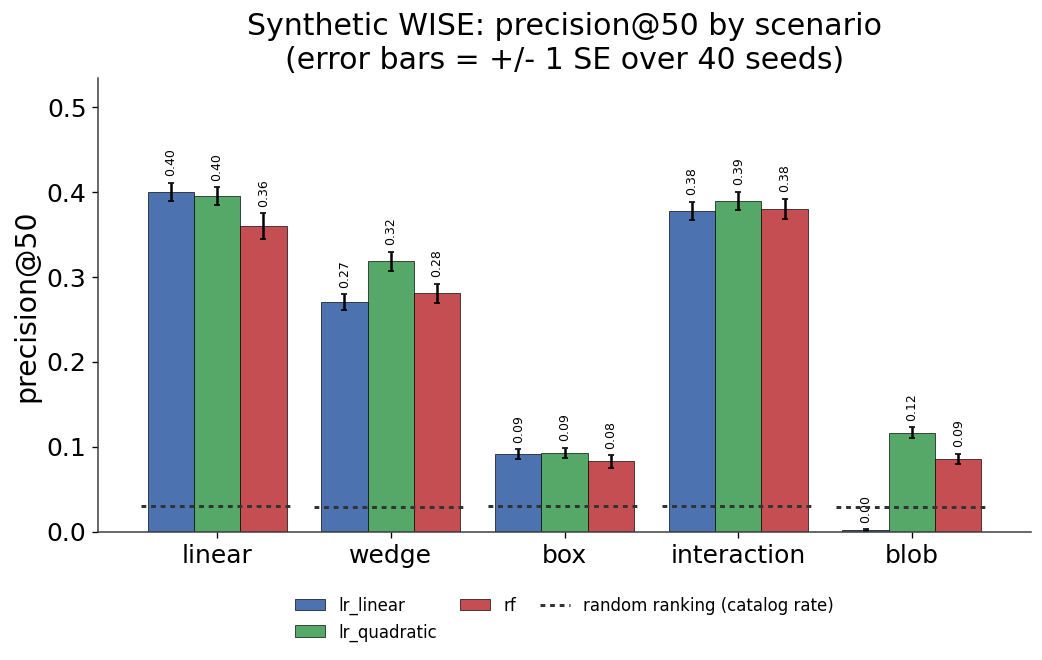

saved poster_figs/wise_pvd_by_scenario.png


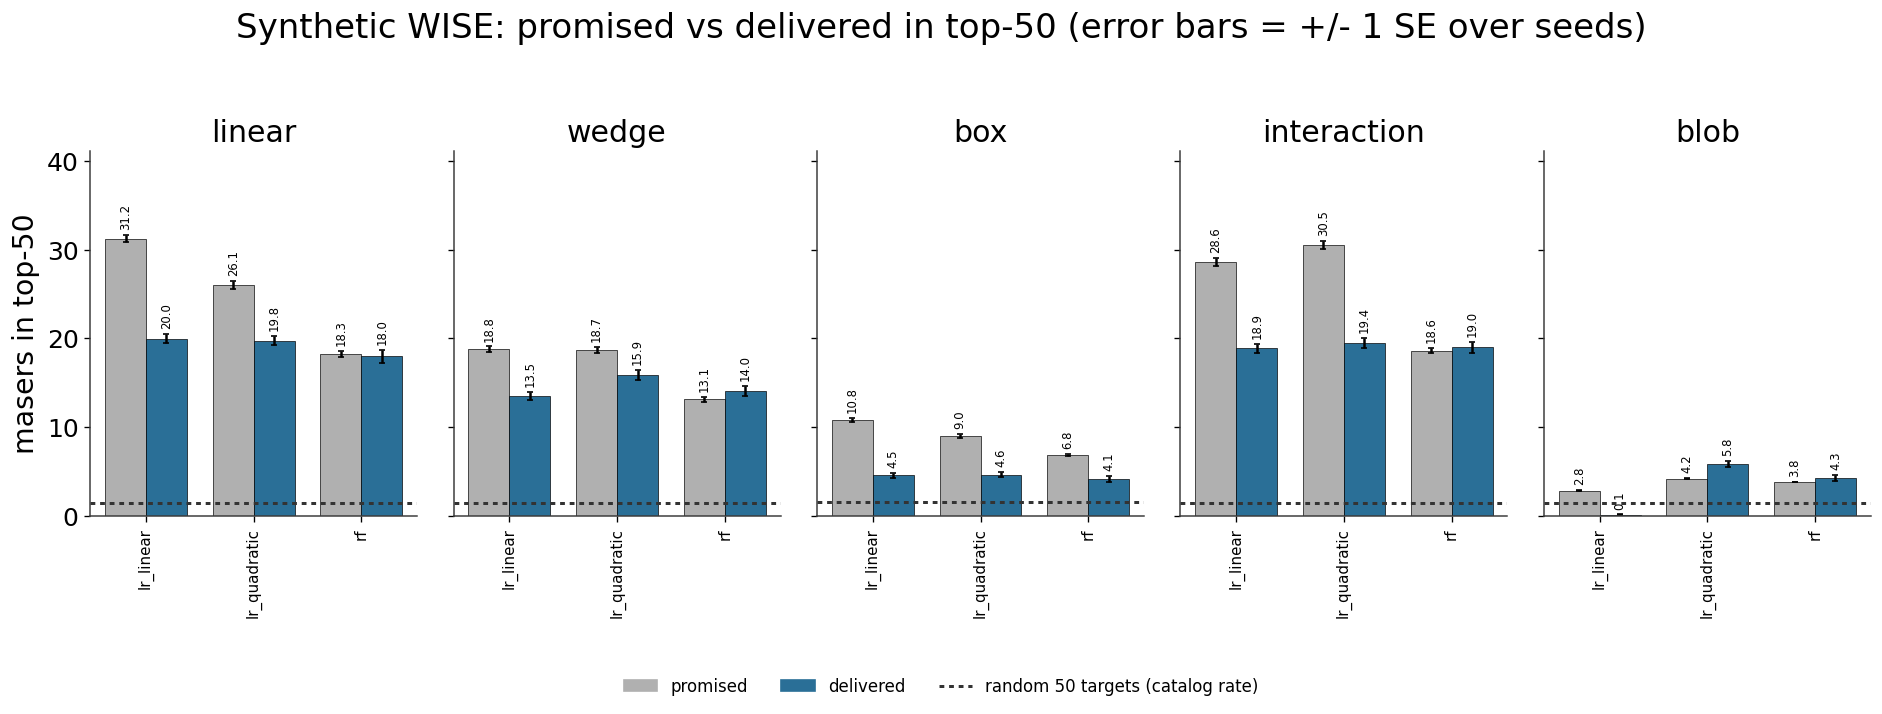

saved poster_figs/wise_brier_skill_by_scenario.png


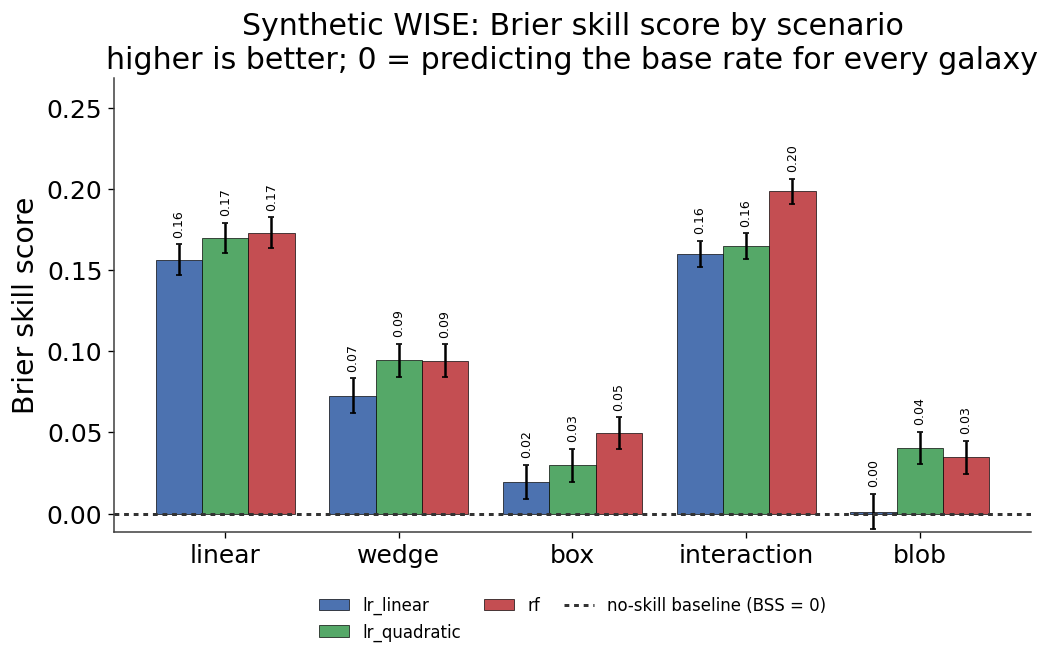

saved poster_figs/wise_pvd_calibration.png


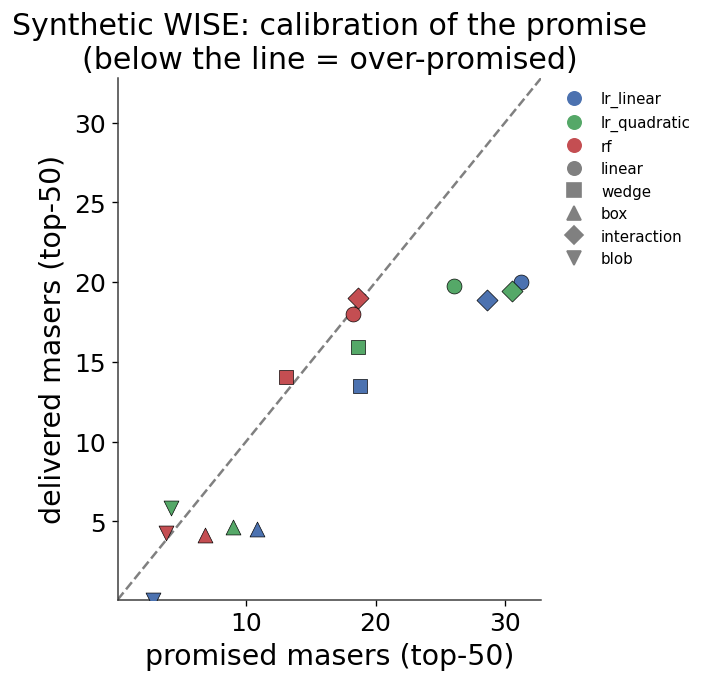

In [85]:
for tag, label, res in [("xray",  "Synthetic X-ray", xray_results),
                        ("wise",  "Synthetic WISE",  wise_results)]:
    key = f"synth_{tag}"
    plot_prec_by_scenario(res, label, tag, PREV[key])
    plot_pvd_by_scenario(res, label, tag, PREV[key])
    plot_brier_skill_by_scenario(res, label, tag, PREV[key])
    plot_pvd_calibration(res, label, tag)

## 10. Summary

This notebook evaluates four candidate models — a plain logistic regression baseline (lr_linear), a quadratic logistic regression, a random forest, and sklearn's histogram gradient boosting classifier — separately on three feature planes (X-ray, WISE, and fused). Hyperparameters were already chosen in separate sweep notebooks using seeds 0–4; this notebook only runs on seeds 5–44 (40 seeds), so no result here benefited from the data used to tune it.

Data. For each of five true decision-boundary shapes (linear, wedge, box, interaction, blob) and each seed, synth_data generates one synthetic catalog per plane, matching real catalog sizes and prevalence (X-ray: n=641, 8.3%; WISE: n=4400, 3.0%; fused: n=602, 8.3%). strength=3.0 sets class separability and ceiling=0.4 caps the maximum true probability any galaxy can have; both are asserted at startup so a stale copy of the generator fails immediately. Real catalogs appear once, in a context-only plot — no model is ever fit on them.

Evaluation loop. For each (scenario, seed), one catalog is built once and reused across all four models — this makes every model's comparison paired by construction (same galaxies, same folds) and cuts dataset generation 4x. Each model is scored with 5-fold stratified cross-validation (StratifiedKFold, shuffle=True, fold seed = 1000*seed + repeat), 1 repeat. Predictions are collected out-of-fold across all 5 folds into one array, with asserts guarding against empty folds or unpredicted rows. Metrics are computed once on that full out-of-fold array (not averaged per-fold), then averaged over repeats.

Metrics. Primary: prec_at_n (precision in the top 50 ranked predictions) and mse_vs_truth (squared error against the generator's true probability, valid since p_obs == p_true is asserted). Diagnostic: Brier score, PR-AUC, ROC-AUC. Also tracked: total predicted maser count vs. actual vs. oracle (sum of true probabilities), to check whether a model's confidence is calibrated or inflated.

Aggregation. summarize() gives mean ± standard error over the 40 seeds per model/scenario. paired_table() computes per-seed differences against lr_linear, joined on (scenario, seed) — since datasets are shared, this cancels catalog-level noise and yields much tighter standard errors than comparing raw means; differences with |t| ≥ 2 are flagged. Section 7 reruns the fused-plane winner on 10 seeds with all features vs. X-ray-only features on the same catalogs, to isolate the value WISE adds. Section 8 compares planes (noting prec_at_n isn't comparable across planes due to differing n/prevalence). Section 9 generates the final summary figures.
